# Task 1 — Logistic Regression


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve,
                             precision_score, recall_score, f1_score,
                             accuracy_score)
import pickle

# Load preprocessed data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train_clf.csv').squeeze()
y_test  = pd.read_csv('../data/y_test_clf.csv').squeeze()

print("✅ Data loaded!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"\nClass distribution in training:")
print(y_train.value_counts())
print(f"\n0 = Fail  |  1 = Pass")

✅ Data loaded!
Training samples: 316
Testing samples:  79

Class distribution in training:
pass_fail
1    213
0    103
Name: count, dtype: int64

0 = Fail  |  1 = Pass


In [2]:
# Build Logistic Regression — just 2 lines!
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

# Make predictions
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

print("✅ Logistic Regression trained!")
print(f"\nSample predictions (first 10):")
print(f"Actual:    {list(y_test[:10].astype(int))}")
print(f"Predicted: {list(y_pred_lr[:10])}")

✅ Logistic Regression trained!

Sample predictions (first 10):
Actual:    [1, 1, 0, 1, 0, 1, 1, 0, 0, 1]
Predicted: [np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1)]


# Task 2 — Confusion Matrix + Metrics

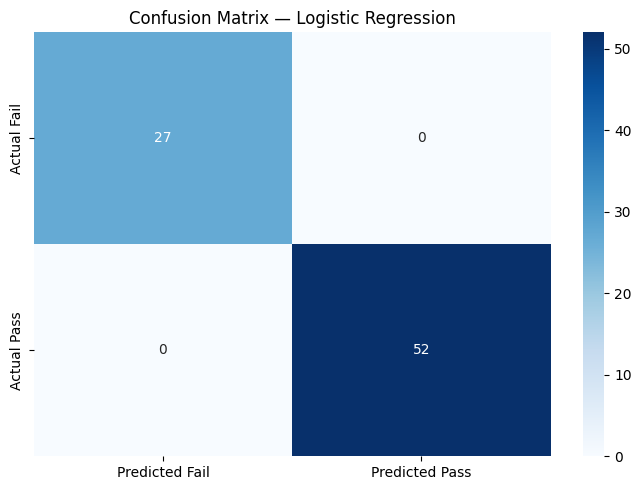


True Positives  (Predicted Pass, Actually Pass): 52
True Negatives  (Predicted Fail, Actually Fail): 27
False Positives (Predicted Pass, Actually Fail): 0 ← Wrong!
False Negatives (Predicted Fail, Actually Pass): 0 ← Wrong!


In [3]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'])
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('../notebooks/chart13_confusion_matrix_lr.png')
plt.show()

# Extract values
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives  (Predicted Pass, Actually Pass): {tp}")
print(f"True Negatives  (Predicted Fail, Actually Fail): {tn}")
print(f"False Positives (Predicted Pass, Actually Fail): {fp} ← Wrong!")
print(f"False Negatives (Predicted Fail, Actually Pass): {fn} ← Wrong!")

In [4]:
# All classification metrics — Unit 2 syllabus!
accuracy  = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall    = recall_score(y_test, y_pred_lr)
f1        = f1_score(y_test, y_pred_lr)
auc       = roc_auc_score(y_test, y_prob_lr)

print("\n" + "="*45)
print("   LOGISTIC REGRESSION RESULTS")
print("="*45)
print(f"Accuracy:   {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1 Score:   {f1:.4f}")
print(f"ROC-AUC:    {auc:.4f}")
print("="*45)


   LOGISTIC REGRESSION RESULTS
Accuracy:   1.0000  (100.0%)
Precision:  1.0000
Recall:     1.0000
F1 Score:   1.0000
ROC-AUC:    1.0000


# Task 3 — ROC-AUC Curve

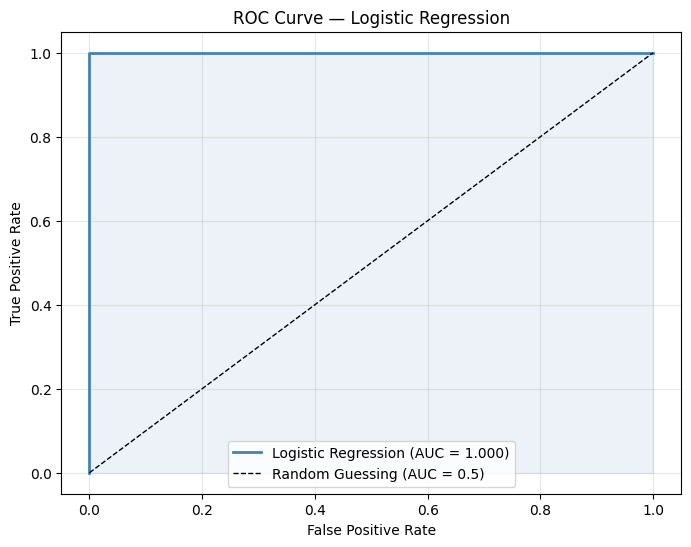

✅ ROC curve saved!


In [5]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Random Guessing (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../notebooks/chart14_roc_curve_lr.png')
plt.show()
print("✅ ROC curve saved!")

# Task 4 — Naive Bayes

In [6]:
# Build Naive Bayes model
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

# Make predictions
y_pred_nb = model_nb.predict(X_test)
y_prob_nb = model_nb.predict_proba(X_test)[:, 1]

print("✅ Naive Bayes trained!")

# Metrics
accuracy_nb  = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb    = recall_score(y_test, y_pred_nb)
f1_nb        = f1_score(y_test, y_pred_nb)
auc_nb       = roc_auc_score(y_test, y_prob_nb)

print("\n" + "="*45)
print("      NAIVE BAYES RESULTS")
print("="*45)
print(f"Accuracy:   {accuracy_nb:.4f}  ({accuracy_nb*100:.1f}%)")
print(f"Precision:  {precision_nb:.4f}")
print(f"Recall:     {recall_nb:.4f}")
print(f"F1 Score:   {f1_nb:.4f}")
print(f"ROC-AUC:    {auc_nb:.4f}")
print("="*45)

✅ Naive Bayes trained!

      NAIVE BAYES RESULTS
Accuracy:   1.0000  (100.0%)
Precision:  1.0000
Recall:     1.0000
F1 Score:   1.0000
ROC-AUC:    1.0000


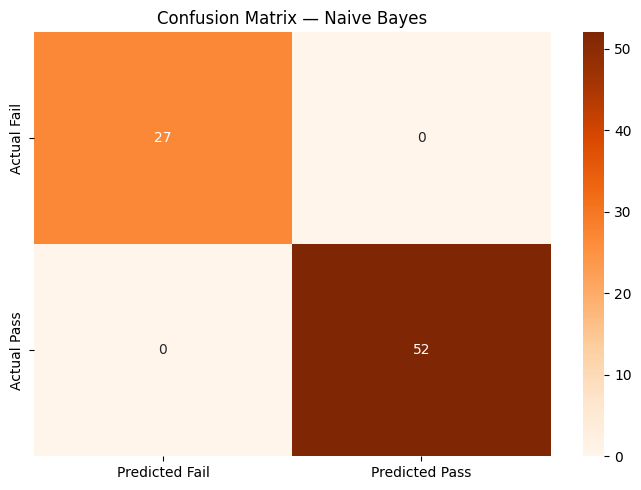

✅ Naive Bayes confusion matrix saved!


In [7]:
# Confusion Matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'])
plt.title('Confusion Matrix — Naive Bayes')
plt.tight_layout()
plt.savefig('../notebooks/chart15_confusion_matrix_nb.png')
plt.show()
print("✅ Naive Bayes confusion matrix saved!")

# Task 5 — Compare Both Models


In [8]:
# Side by side comparison table
print("\n" + "="*55)
print("           MODEL COMPARISON")
print("="*55)
print(f"{'Metric':<12} {'Logistic Reg':>18} {'Naive Bayes':>18}")
print("-"*55)
print(f"{'Accuracy':<12} {accuracy:>18.4f} {accuracy_nb:>18.4f}")
print(f"{'Precision':<12} {precision:>18.4f} {precision_nb:>18.4f}")
print(f"{'Recall':<12} {recall:>18.4f} {recall_nb:>18.4f}")
print(f"{'F1 Score':<12} {f1:>18.4f} {f1_nb:>18.4f}")
print(f"{'ROC-AUC':<12} {auc:>18.4f} {auc_nb:>18.4f}")
print("="*55)

winner = "Logistic Regression" if auc > auc_nb else "Naive Bayes"
print(f"\n🏆 Winner: {winner}!")


           MODEL COMPARISON
Metric             Logistic Reg        Naive Bayes
-------------------------------------------------------
Accuracy                 1.0000             1.0000
Precision                1.0000             1.0000
Recall                   1.0000             1.0000
F1 Score                 1.0000             1.0000
ROC-AUC                  1.0000             1.0000

🏆 Winner: Naive Bayes!


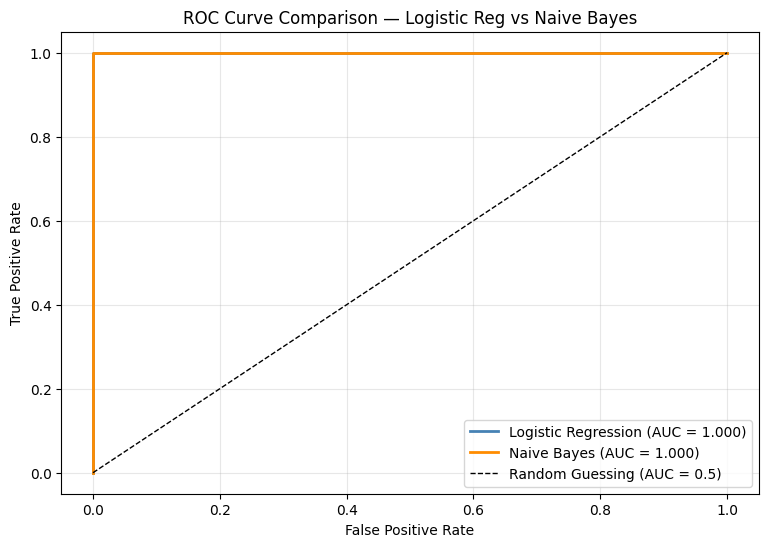

✅ ROC comparison chart saved!


In [9]:
# ROC curves — both on same chart!
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)

plt.figure(figsize=(9, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot(fpr_nb, tpr_nb, color='darkorange', linewidth=2,
         label=f'Naive Bayes (AUC = {auc_nb:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Random Guessing (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — Logistic Reg vs Naive Bayes')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../notebooks/chart16_roc_comparison.png')
plt.show()
print("✅ ROC comparison chart saved!")

# Task 6 — Save Models

In [10]:
import os
os.makedirs('../models', exist_ok=True)

# Save both models
with open('../models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(model_lr, f)

with open('../models/naive_bayes.pkl', 'wb') as f:
    pickle.dump(model_nb, f)

print("✅ Both models saved!")
print("\n" + "="*45)
print("        DAY 5 COMPLETE!")
print("="*45)
print(f"Logistic Regression Accuracy: {accuracy*100:.1f}%")
print(f"Naive Bayes Accuracy:         {accuracy_nb*100:.1f}%")
print(f"Best model:                   {winner}")
print("="*45)

✅ Both models saved!

        DAY 5 COMPLETE!
Logistic Regression Accuracy: 100.0%
Naive Bayes Accuracy:         100.0%
Best model:                   Naive Bayes
